# Advanced Coding Test v3 — Unified Time-Series AI

기존 코딩 테스트와 발표자료의 기술적 문제의식을 하나의 재현 가능한 연구 파이프라인으로 통합한 버전입니다.

```text
PART 0. Reproducibility / Environment
PART 1. Data Engineering
        ├─ Pandas / NumPy baseline
        ├─ Numba accelerated routines
        └─ Awkward Array ragged-event representation
PART 2. Unified Temporal Encoder
        ├─ Attention
        ├─ Local temporal convolution
        └─ Latent representation API
PART 3. Deterministic Forecasting — ETTh1
        ├─ Persistence
        └─ UnifiedTS Forecast
PART 4. Generative Forecasting — Conditional Diffusion
        ├─ Forward diffusion q(x_t | x_0)
        ├─ Conditional denoiser εθ
        ├─ Reverse sampling
        ├─ Monte-Carlo future paths
        └─ Probabilistic metrics
PART 5. Anomaly Detection — PSM
PART 6. Ragged Event Analysis
PART 7. High-performance Evaluation
PART 8. Classification — Libras
PART 9. Latent Representation Analysis
PART 10. Stability
PART 11. Real Financial Market Extension
PART 12. Final Benchmark Dashboard
```

설계 원칙:
- 개인정보 미포함
- train-only preprocessing
- 시간순서 보존
- test label을 threshold tuning에 사용하지 않음
- baseline 비교
- Diffusion은 1D conditional model로 직접 구현
- Numba/Awkward Array를 실제 파이프라인에 연결

# PART 0. Reproducibility / Environment

`QUICK_RUN=True`는 전체 파이프라인 연결 검증용입니다. 본 실험은 `False`로 바꿉니다.

In [1]:
%pip -q install "numba>=0.61" "awkward>=2.8" "aeon>=1.4,<1.6" \
    "huggingface_hub>=0.30" "statsmodels>=0.14" "yfinance>=0.2.50"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.8/698.8 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.


In [2]:
import os, json, math, random, time, platform, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
from numba import njit, prange

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.covariance import OAS
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, silhouette_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download
from aeon.datasets import load_classification

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = True
RUN_DIFFUSION = True
RUN_LATENT_ANALYSIS = True
RUN_STABILITY = False
RUN_MARKET_CASE_STUDY = False

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.set_float32_matmul_precision("high")

ROOT = Path("./coding_test_advanced_v3")
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("Device:", DEVICE)

Python: 3.12.13
Torch: 2.11.0+cu128
Device: cuda


In [3]:
@dataclass
class CommonConfig:
    seed: int = 42
    num_workers: int = 0
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    patience: int = 4

@dataclass
class ForecastConfig:
    seq_len: int = 96
    pred_len: int = 96
    batch_size: int = 64
    epochs: int = 3 if QUICK_RUN else 20
    lr: float = 1e-3
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.1

@dataclass
class DiffusionConfig:
    timesteps: int = 30 if QUICK_RUN else 100
    epochs: int = 3 if QUICK_RUN else 25
    batch_size: int = 64
    lr: float = 8e-4
    hidden: int = 64
    n_blocks: int = 4
    n_samples: int = 8 if QUICK_RUN else 50
    max_eval_windows: int = 128 if QUICK_RUN else 1024

@dataclass
class AnomalyConfig:
    win_size: int = 100
    train_step: int = 10 if QUICK_RUN else 5
    eval_step: int = 5 if QUICK_RUN else 1
    batch_size: int = 128
    epochs: int = 3 if QUICK_RUN else 15
    lr: float = 1e-3
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.1
    threshold_quantile: float = 0.995
    mask_ratio: float = 0.15

@dataclass
class ClassificationConfig:
    batch_size: int = 32
    epochs: int = 8 if QUICK_RUN else 40
    lr: float = 8e-4
    d_model: int = 64
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.15

COMMON = CommonConfig()
F_CFG = ForecastConfig()
D_CFG = DiffusionConfig()
A_CFG = AnomalyConfig()
C_CFG = ClassificationConfig()

def save_json(obj, path):
    def conv(x):
        if isinstance(x, (np.integer, np.floating)):
            return x.item()
        if isinstance(x, np.ndarray):
            return x.tolist()
        return str(x)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=conv)

def loader(ds, batch_size, shuffle=False):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=COMMON.num_workers,
        pin_memory=(DEVICE.type == "cuda"), drop_last=False,
    )

def plot_history(history, title):
    plt.figure(figsize=(7, 3.5))
    for col in history.columns:
        if col != "epoch":
            plt.plot(history["epoch"], history[col], marker="o", label=col)
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

# PART 1. Data Engineering

- ETTh1 / PSM / Libras acquisition
- Python loop / Numba / NumPy runtime comparison
- Awkward Array variable-length representation
- train-only preprocessing 원칙

In [4]:
HF_REPO = "thuml/Time-Series-Library"

def hf_dataset_file(filename):
    return hf_hub_download(
        repo_id=HF_REPO, filename=filename,
        repo_type="dataset", cache_dir=str(DATA_DIR / "hf_cache")
    )

def load_etth1_raw():
    df = pd.read_csv(hf_dataset_file("ETT-small/ETTh1.csv"))
    df["date"] = pd.to_datetime(df["date"])
    return df

def load_psm_raw():
    return (
        pd.read_csv(hf_dataset_file("PSM/train.csv")),
        pd.read_csv(hf_dataset_file("PSM/test.csv")),
        pd.read_csv(hf_dataset_file("PSM/test_label.csv")),
    )

def load_libras_raw():
    Xtr, ytr = load_classification("Libras", split="train", load_equal_length=True)
    Xte, yte = load_classification("Libras", split="test", load_equal_length=True)
    return Xtr, ytr, Xte, yte

In [5]:
def standardize_python_loop(x):
    x = np.asarray(x, dtype=np.float64)
    out = np.empty_like(x)
    n, c = x.shape
    for j in range(c):
        mu = float(np.mean(x[:, j]))
        sd = float(np.std(x[:, j])) + 1e-12
        for i in range(n):
            out[i, j] = (x[i, j] - mu) / sd
    return out

@njit(parallel=True)
def standardize_numba(x):
    n, c = x.shape
    out = np.empty_like(x)
    for j in prange(c):
        mu = 0.0
        for i in range(n):
            mu += x[i, j]
        mu /= n

        var = 0.0
        for i in range(n):
            d = x[i, j] - mu
            var += d * d
        sd = math.sqrt(var / n) + 1e-12

        for i in range(n):
            out[i, j] = (x[i, j] - mu) / sd
    return out

def standardize_numpy(x):
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True) + 1e-12
    return (x - mu) / sd

def benchmark_standardizers(x, python_rows=5000):
    x = np.asarray(x, dtype=np.float64)
    xp = x[:min(python_rows, len(x))]
    _ = standardize_numba(xp[:min(128, len(xp))])

    t0 = time.perf_counter()
    py = standardize_python_loop(xp)
    t_python = time.perf_counter() - t0

    t0 = time.perf_counter()
    nbv = standardize_numba(xp)
    t_numba = time.perf_counter() - t0

    t0 = time.perf_counter()
    npv = standardize_numpy(xp)
    t_numpy = time.perf_counter() - t0

    assert np.allclose(py, nbv, atol=1e-10)
    assert np.allclose(py, npv, atol=1e-10)

    return pd.DataFrame({
        "implementation": ["Python loop", "Numba JIT", "NumPy vectorized"],
        "seconds": [t_python, t_numba, t_numpy],
    })

def make_ragged_sequences(values, min_len=24, max_len=168, stride=48, seed=SEED):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    seqs = []
    for start in range(0, max(0, len(values) - max_len), stride):
        length = int(rng.integers(min_len, max_len + 1))
        seqs.append(values[start:start+length].tolist())
    return ak.Array(seqs)

def ragged_summary(ragged):
    lengths = ak.num(ragged, axis=1)
    return {
        "n_sequences": int(len(ragged)),
        "min_length": int(ak.min(lengths)),
        "max_length": int(ak.max(lengths)),
        "mean_length": float(ak.mean(lengths)),
    }

In [6]:
etth1 = load_etth1_raw()
value_cols = [c for c in etth1.columns if c != "date"]

engineering_benchmark = benchmark_standardizers(
    etth1[value_cols].to_numpy(dtype=np.float64)
)
display(engineering_benchmark)

ragged_etth1 = make_ragged_sequences(
    etth1[value_cols].to_numpy(dtype=np.float64),
    min_len=24, max_len=168,
    stride=72 if QUICK_RUN else 24,
)
print("Awkward type:", ak.type(ragged_etth1))
print(ragged_summary(ragged_etth1))

engineering_benchmark.to_csv(
    ARTIFACT_DIR / "data_engineering_runtime.csv", index=False
)

ETTh1.csv:   0%|          | 0.00/2.59M [00:00<?, ?B/s]

,implementation,seconds
0,Python loop,0.028297
1,Numba JIT,0.000453
2,NumPy vectorized,0.001001


Awkward type: 240 * var * var * float64
{'n_sequences': 240, 'min_length': 25, 'max_length': 168, 'mean_length': 97.5125}


# PART 2. Unified Temporal Encoder

공통 backbone:
1. channel projection
2. local Conv1D
3. positional encoding
4. 직접 구현한 multi-head attention
5. latent `encode()` API

task head:
- forecast: learned future query + cross-attention
- anomaly: timestep reconstruction
- classification: attention pooling

In [7]:
def sinusoidal_encoding(length, dim, device, dtype):
    pos = torch.arange(length, device=device, dtype=dtype).unsqueeze(1)
    even = torch.arange(0, dim, 2, device=device, dtype=dtype)
    div = torch.exp(-math.log(10000.0) * even / dim)
    pe = torch.zeros(length, dim, device=device, dtype=dtype)
    pe[:, 0::2] = torch.sin(pos * div)
    if dim > 1:
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
    return pe

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split(self, x):
        B, L, D = x.shape
        return x.view(B, L, self.n_heads, self.d_head).transpose(1, 2)

    def forward(self, q, kv=None):
        if kv is None:
            kv = q
        Q = self._split(self.q_proj(q))
        K = self._split(self.k_proj(kv))
        V = self._split(self.v_proj(kv))
        score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = self.dropout(torch.softmax(score, dim=-1))
        z = torch.matmul(attn, V)
        z = z.transpose(1, 2).contiguous().view(q.shape[0], q.shape[1], self.d_model)
        return self.out_proj(z)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout, ff_mult=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_mult*d_model, d_model), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

class TemporalEncoder(nn.Module):
    def __init__(self, in_channels, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.local_conv = nn.Conv1d(d_model, d_model, 3, padding=1)
        self.local_norm = nn.LayerNorm(d_model)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.out_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        z = self.input_proj(x)
        local = self.local_conv(z.transpose(1, 2)).transpose(1, 2)
        z = self.local_norm(z + F.gelu(local))
        z = z + sinusoidal_encoding(
            z.shape[1], z.shape[2], z.device, z.dtype
        ).unsqueeze(0)
        z = self.dropout(z)
        for block in self.blocks:
            z = block(z)
        return self.out_norm(z)

class ForecastHead(nn.Module):
    def __init__(self, d_model, n_heads, out_channels, pred_len, dropout):
        super().__init__()
        self.pred_len = pred_len
        self.query = nn.Parameter(torch.randn(pred_len, d_model) * 0.02)
        self.cross = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 2*d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(2*d_model, d_model)
        )
        self.out = nn.Linear(d_model, out_channels)

    def forward(self, memory):
        B = memory.shape[0]
        q = self.query.unsqueeze(0).expand(B, -1, -1)
        q = q + sinusoidal_encoding(
            self.pred_len, q.shape[-1], q.device, q.dtype
        ).unsqueeze(0)
        q = q + self.cross(self.norm(q), memory)
        q = q + self.ff(self.norm(q))
        return self.out(q)

class AttentionPool(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, z):
        w = torch.softmax(self.score(z).squeeze(-1), dim=-1)
        return torch.sum(z * w.unsqueeze(-1), dim=1)

class UnifiedTSModel(nn.Module):
    def __init__(
        self, task, in_channels, d_model=64, n_heads=4, n_layers=2,
        dropout=0.1, pred_len=None, n_classes=None
    ):
        super().__init__()
        self.task = task
        self.encoder = TemporalEncoder(
            in_channels, d_model, n_heads, n_layers, dropout
        )
        if task == "forecast":
            self.head = ForecastHead(
                d_model, n_heads, in_channels, pred_len, dropout
            )
        elif task == "anomaly":
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(d_model, in_channels)
            )
        elif task == "classification":
            self.pool = AttentionPool(d_model)
            self.head = nn.Sequential(
                nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
                nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, n_classes)
            )
        else:
            raise ValueError(task)

    def encode_tokens(self, x):
        return self.encoder(x)

    def encode(self, x, pool="mean"):
        z = self.encode_tokens(x)
        if pool == "mean":
            return z.mean(dim=1)
        if pool == "last":
            return z[:, -1]
        if pool == "attention" and hasattr(self, "pool"):
            return self.pool(z)
        raise ValueError(pool)

    def forward(self, x):
        z = self.encode_tokens(x)
        if self.task == "classification":
            return self.head(self.pool(z))
        return self.head(z)

In [8]:
@torch.no_grad()
def model_shape_smoke_test():
    mf = UnifiedTSModel("forecast", 7, 32, 4, 1, 0.0, pred_len=24)
    assert mf(torch.randn(3, 96, 7)).shape == (3, 24, 7)
    assert mf.encode(torch.randn(3, 96, 7)).shape == (3, 32)

    ma = UnifiedTSModel("anomaly", 25, 32, 4, 1, 0.0)
    assert ma(torch.randn(3, 100, 25)).shape == (3, 100, 25)

    mc = UnifiedTSModel("classification", 2, 32, 4, 1, 0.0, n_classes=15)
    assert mc(torch.randn(3, 45, 2)).shape == (3, 15)
    print("✓ UnifiedTS shape smoke test passed")

model_shape_smoke_test()

✓ UnifiedTS shape smoke test passed


## Shared Dataset / Training Utilities

In [9]:
class ForecastWindowDataset(Dataset):
    def __init__(self, data, target_start, target_end, seq_len, pred_len):
        self.data = np.asarray(data, dtype=np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        first = max(target_start, seq_len)
        last = target_end - pred_len
        if last < first:
            raise ValueError("split too short")
        self.target_starts = np.arange(first, last + 1, dtype=np.int64)

    def __len__(self):
        return len(self.target_starts)

    def __getitem__(self, idx):
        t = int(self.target_starts[idx])
        x = self.data[t-self.seq_len:t]
        y = self.data[t:t+self.pred_len]
        return torch.from_numpy(x), torch.from_numpy(y)

class AnomalyWindowDataset(Dataset):
    def __init__(self, data, win_size, step):
        self.data = np.asarray(data, dtype=np.float32)
        self.win_size = win_size
        max_start = len(self.data) - win_size
        if max_start < 0:
            raise ValueError("data shorter than win_size")
        starts = list(range(0, max_start + 1, step))
        if starts[-1] != max_start:
            starts.append(max_start)
        self.starts = np.asarray(starts, dtype=np.int64)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = int(self.starts[idx])
        x = self.data[s:s+self.win_size]
        return torch.from_numpy(x), torch.tensor(s, dtype=torch.long)

class ClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float32).transpose(0, 2, 1)
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)

class EarlyStopper:
    def __init__(self, patience=4):
        self.patience = patience
        self.best = float("inf")
        self.count = 0

    def step(self, value):
        improved = value < self.best - 1e-10
        if improved:
            self.best = value
            self.count = 0
        else:
            self.count += 1
        return improved, self.count >= self.patience

def fit_mse_task(model, train_loader, val_loader, epochs, lr, checkpoint_path, task, mask_ratio=0.0):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=COMMON.weight_decay)
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            if task == "forecast":
                x, target = batch
                model_input = x
            else:
                x, _ = batch
                target = x
                if mask_ratio > 0:
                    mask = torch.rand_like(x) < mask_ratio
                    model_input = x.masked_fill(mask, 0.0)
                else:
                    model_input = x

            model_input = model_input.to(DEVICE)
            target = target.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model(model_input)
            loss = F.mse_loss(pred, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                if task == "forecast":
                    x, target = batch
                else:
                    x, _ = batch
                    target = x
                x = x.to(DEVICE)
                target = target.to(DEVICE)
                val_losses.append(F.mse_loss(model(x), target).item())

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(row)

        improved, stop = stopper.step(row["val_loss"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

def fit_classifier(model, train_loader, val_loader, epochs, lr, checkpoint_path):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=COMMON.weight_decay)
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses, correct, total = [], 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()
            losses.append(loss.item())
            correct += (logits.argmax(-1) == y).sum().item()
            total += y.numel()

        model.eval()
        vlosses, vcorrect, vtotal = [], 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                vlosses.append(F.cross_entropy(logits, y).item())
                vcorrect += (logits.argmax(-1) == y).sum().item()
                vtotal += y.numel()

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "train_acc": correct / total,
            "val_loss": float(np.mean(vlosses)),
            "val_acc": vcorrect / vtotal,
        }
        history.append(row)
        print(row)
        improved, stop = stopper.step(row["val_loss"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

# PART 3. Deterministic Forecasting — ETTh1

Persistence와 UnifiedTS direct multi-horizon forecasting을 비교합니다.
전처리는 시간순서 70/10/20 split에서 train에만 fit합니다.

In [10]:
n = len(etth1)
train_end = int(n * 0.70)
val_end = int(n * 0.80)
raw_values = etth1[value_cols].to_numpy(dtype=np.float64)

f_imputer = SimpleImputer(strategy="median")
f_scaler = StandardScaler()
train_values = f_imputer.fit_transform(raw_values[:train_end])
f_scaler.fit(train_values)
all_scaled = f_scaler.transform(
    f_imputer.transform(raw_values)
).astype(np.float32)

f_train_ds = ForecastWindowDataset(all_scaled, 0, train_end, F_CFG.seq_len, F_CFG.pred_len)
f_val_ds = ForecastWindowDataset(all_scaled, train_end, val_end, F_CFG.seq_len, F_CFG.pred_len)
f_test_ds = ForecastWindowDataset(all_scaled, val_end, n, F_CFG.seq_len, F_CFG.pred_len)

f_train_loader = loader(f_train_ds, F_CFG.batch_size, shuffle=True)
f_val_loader = loader(f_val_ds, F_CFG.batch_size)
f_test_loader = loader(f_test_ds, F_CFG.batch_size)

print("forecast windows:", len(f_train_ds), len(f_val_ds), len(f_test_ds))

forecast windows: 12003 1647 3389


{'epoch': 1, 'train_loss': 0.5458584443685857, 'val_loss': 0.5880301606196624}
{'epoch': 2, 'train_loss': 0.3517710138508614, 'val_loss': 0.5533228585353265}
{'epoch': 3, 'train_loss': 0.2879805836747301, 'val_loss': 0.6898751430786573}


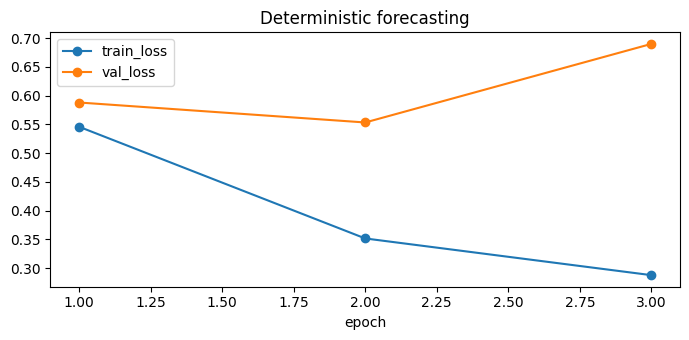

In [11]:
forecast_model = UnifiedTSModel(
    "forecast", len(value_cols),
    F_CFG.d_model, F_CFG.n_heads, F_CFG.n_layers, F_CFG.dropout,
    pred_len=F_CFG.pred_len
)
forecast_ckpt = ARTIFACT_DIR / "forecast_best.pt"
forecast_model, forecast_history = fit_mse_task(
    forecast_model, f_train_loader, f_val_loader,
    F_CFG.epochs, F_CFG.lr, forecast_ckpt, "forecast"
)
forecast_history.to_csv(ARTIFACT_DIR / "forecast_history.csv", index=False)
plot_history(forecast_history, "Deterministic forecasting")

{
  "model_all": {
    "MAE": 2.2706754207611084,
    "MSE": 14.77572250366211,
    "RMSE": 3.843920199960206
  },
  "persistence_all": {
    "MAE": 3.5087008476257324,
    "MSE": 45.77716827392578,
    "RMSE": 6.765882667762262
  },
  "model_OT": {
    "MAE": 2.9145002365112305,
    "MSE": 13.445548057556152,
    "RMSE": 3.666817156275474
  },
  "persistence_OT": {
    "MAE": 2.300907850265503,
    "MSE": 9.18354320526123,
    "RMSE": 3.0304361410960685
  }
}


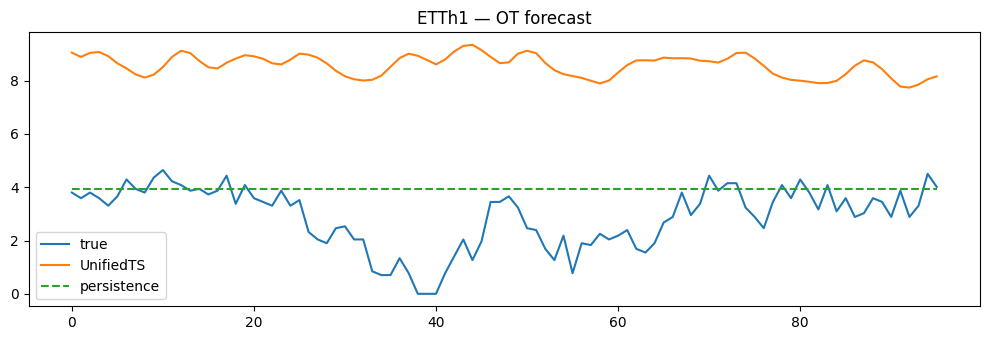

In [12]:
@torch.no_grad()
def evaluate_forecast(model, data_loader, scaler, feature_names):
    model.eval()
    preds, targets, persistence = [], [], []

    for x, y in data_loader:
        pred = model(x.to(DEVICE)).cpu().numpy()
        x_np, y_np = x.numpy(), y.numpy()
        base = np.repeat(x_np[:, -1:, :], y_np.shape[1], axis=1)
        preds.append(pred)
        targets.append(y_np)
        persistence.append(base)

    pred_s = np.concatenate(preds)
    true_s = np.concatenate(targets)
    base_s = np.concatenate(persistence)
    C = true_s.shape[-1]

    pred = scaler.inverse_transform(pred_s.reshape(-1, C)).reshape(pred_s.shape)
    true = scaler.inverse_transform(true_s.reshape(-1, C)).reshape(true_s.shape)
    base = scaler.inverse_transform(base_s.reshape(-1, C)).reshape(base_s.shape)

    def metric(y, p):
        mse = mean_squared_error(y.reshape(-1), p.reshape(-1))
        return {
            "MAE": mean_absolute_error(y.reshape(-1), p.reshape(-1)),
            "MSE": mse,
            "RMSE": math.sqrt(mse),
        }

    ot_idx = feature_names.index("OT") if "OT" in feature_names else -1
    return {
        "model_all": metric(true, pred),
        "persistence_all": metric(true, base),
        "model_OT": metric(true[:, :, ot_idx], pred[:, :, ot_idx]),
        "persistence_OT": metric(true[:, :, ot_idx], base[:, :, ot_idx]),
    }, pred, true, base

forecast_metrics, f_pred, f_true, f_base = evaluate_forecast(
    forecast_model, f_test_loader, f_scaler, value_cols
)
print(json.dumps(forecast_metrics, indent=2))
save_json(forecast_metrics, ARTIFACT_DIR / "forecast_metrics.json")

ot_idx = value_cols.index("OT") if "OT" in value_cols else -1
plt.figure(figsize=(10, 3.5))
plt.plot(f_true[0, :, ot_idx], label="true")
plt.plot(f_pred[0, :, ot_idx], label="UnifiedTS")
plt.plot(f_base[0, :, ot_idx], "--", label="persistence")
plt.title("ETTh1 — OT forecast")
plt.legend()
plt.tight_layout()
plt.show()

# PART 4. Generative Forecasting — Conditional Diffusion

기존의 2D reshape 방식 대신 미래 시계열을 `[batch, horizon, channels]` 그대로 유지하는 1D conditional DDPM입니다.

Forward:
\[
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
\]

Denoiser:
\[
\epsilon_\theta(x_t,t,x_{history})
\]

출력은 하나의 미래값이 아니라 Monte-Carlo future paths입니다.

In [13]:
class DiffusionTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, 2*dim), nn.SiLU(), nn.Linear(2*dim, dim)
        )

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            -math.log(10000) * torch.arange(
                half, device=t.device, dtype=torch.float32
            ) / max(half - 1, 1)
        )
        emb = t.float().unsqueeze(1) * freq.unsqueeze(0)
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        if emb.shape[1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[1]))
        return self.mlp(emb)

class ConditionalResBlock1D(nn.Module):
    def __init__(self, hidden, cond_dim, dropout=0.1):
        super().__init__()
        groups = 8 if hidden % 8 == 0 else 1
        self.norm1 = nn.GroupNorm(groups, hidden)
        self.conv1 = nn.Conv1d(hidden, hidden, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, hidden)
        self.norm2 = nn.GroupNorm(groups, hidden)
        self.conv2 = nn.Conv1d(hidden, hidden, 3, padding=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, cond):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.cond_proj(cond).unsqueeze(-1)
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return x + h

class ConditionalDiffusion1D(nn.Module):
    def __init__(
        self, in_channels, context_d_model, context_heads, context_layers,
        hidden, n_blocks, timesteps, dropout=0.1
    ):
        super().__init__()
        self.in_channels = in_channels
        self.timesteps = timesteps

        self.context_encoder = TemporalEncoder(
            in_channels, context_d_model, context_heads, context_layers, dropout
        )
        self.context_proj = nn.Linear(context_d_model, hidden)
        self.time_embed = DiffusionTimeEmbedding(hidden)
        self.in_proj = nn.Conv1d(in_channels, hidden, 1)
        self.blocks = nn.ModuleList([
            ConditionalResBlock1D(hidden, hidden, dropout)
            for _ in range(n_blocks)
        ])
        groups = 8 if hidden % 8 == 0 else 1
        self.out = nn.Sequential(
            nn.GroupNorm(groups, hidden), nn.SiLU(),
            nn.Conv1d(hidden, in_channels, 1)
        )

        betas = torch.linspace(1e-4, 2e-2, timesteps, dtype=torch.float32)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)
        posterior_var = (
            betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
        ).clamp(min=1e-12)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_bar", alpha_bar)
        self.register_buffer("posterior_var", posterior_var)

    def context_vector(self, context):
        return self.context_proj(self.context_encoder(context).mean(dim=1))

    def forward(self, noisy_future, t, context):
        h = self.in_proj(noisy_future.transpose(1, 2))
        cond = self.context_vector(context) + self.time_embed(t)
        for block in self.blocks:
            h = block(h, cond)
        return self.out(h).transpose(1, 2)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        ab = self.alpha_bar[t].view(-1, 1, 1)
        xt = torch.sqrt(ab) * x0 + torch.sqrt(1.0 - ab) * noise
        return xt, noise

In [14]:
def fit_diffusion(model, train_loader, val_loader, epochs, lr, checkpoint_path):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=COMMON.weight_decay
    )
    stopper = EarlyStopper(COMMON.patience)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        tr = []
        for context, future in train_loader:
            context, future = context.to(DEVICE), future.to(DEVICE)
            t = torch.randint(0, model.timesteps, (len(context),), device=DEVICE)
            noisy, noise = model.q_sample(future, t)
            opt.zero_grad(set_to_none=True)
            pred_noise = model(noisy, t, context)
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), COMMON.grad_clip)
            opt.step()
            tr.append(loss.item())

        model.eval()
        va = []
        with torch.no_grad():
            for context, future in val_loader:
                context, future = context.to(DEVICE), future.to(DEVICE)
                t = torch.randint(0, model.timesteps, (len(context),), device=DEVICE)
                noisy, noise = model.q_sample(future, t)
                va.append(F.mse_loss(model(noisy, t, context), noise).item())

        row = {
            "epoch": epoch,
            "train_noise_mse": float(np.mean(tr)),
            "val_noise_mse": float(np.mean(va)),
        }
        history.append(row)
        print(row)

        improved, stop = stopper.step(row["val_noise_mse"])
        if improved:
            torch.save(model.state_dict(), checkpoint_path)
        if stop:
            print("early stopping")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history)

@torch.no_grad()
def ddpm_sample(model, context, pred_len):
    model.eval()
    B = len(context)
    x = torch.randn(B, pred_len, model.in_channels, device=context.device)

    for ti in reversed(range(model.timesteps)):
        t = torch.full((B,), ti, device=context.device, dtype=torch.long)
        eps = model(x, t, context)
        beta = model.betas[ti]
        alpha = model.alphas[ti]
        ab = model.alpha_bar[ti]
        mean = (x - beta / torch.sqrt(1.0 - ab) * eps) / torch.sqrt(alpha)

        if ti > 0:
            x = mean + torch.sqrt(model.posterior_var[ti]) * torch.randn_like(x)
        else:
            x = mean
    return x

@torch.no_grad()
def sample_mc_paths(model, context, pred_len, n_samples):
    samples = []
    for _ in range(n_samples):
        samples.append(ddpm_sample(model, context, pred_len).cpu().numpy())
    return np.stack(samples, axis=0)

In [15]:
def empirical_crps(samples, truth):
    # samples [M,B,H,C], truth [B,H,C]
    # finite-sample CRPS approximation:
    # E|X-y| - 0.5 E|X-X'|
    samples = np.asarray(samples)
    truth = np.asarray(truth)

    term1 = np.mean(np.abs(samples - truth[None, ...]))
    M = samples.shape[0]
    pair_sum, count = 0.0, 0

    for i in range(M):
        for j in range(i + 1, M):
            pair_sum += np.mean(np.abs(samples[i] - samples[j]))
            count += 1

    return float(term1 - 0.5 * pair_sum / max(count, 1))

def probabilistic_metrics(samples, truth):
    mean_pred = samples.mean(axis=0)
    mse = mean_squared_error(truth.reshape(-1), mean_pred.reshape(-1))
    q05, q25, q75, q95 = np.quantile(
        samples, [0.05, 0.25, 0.75, 0.95], axis=0
    )

    return {
        "mean_MAE": mean_absolute_error(truth.reshape(-1), mean_pred.reshape(-1)),
        "mean_RMSE": math.sqrt(mse),
        "CRPS_empirical": empirical_crps(samples, truth),
        "coverage_90": float(np.mean((truth >= q05) & (truth <= q95))),
        "interval_width_90": float(np.mean(q95 - q05)),
        "coverage_50": float(np.mean((truth >= q25) & (truth <= q75))),
        "interval_width_50": float(np.mean(q75 - q25)),
    }

{'epoch': 1, 'train_noise_mse': 0.518961674672492, 'val_noise_mse': 0.425347415300516}
{'epoch': 2, 'train_noise_mse': 0.42150961433319334, 'val_noise_mse': 0.41906783099357897}
{'epoch': 3, 'train_noise_mse': 0.4039846544570111, 'val_noise_mse': 0.41012227420623487}


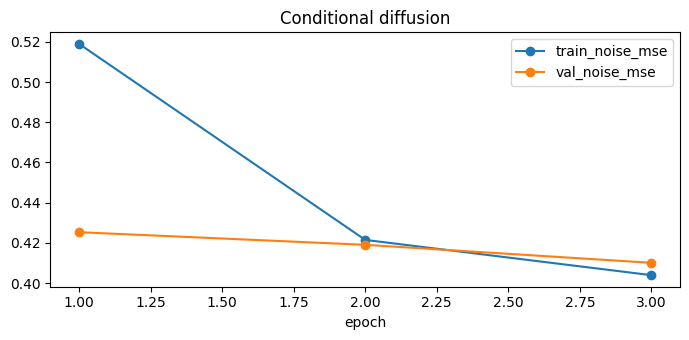

{
  "mean_MAE": 4.766524314880371,
  "mean_RMSE": 7.181744999836445,
  "CRPS_empirical": 3.968475818634033,
  "coverage_90": 0.3636997767857143,
  "interval_width_90": 3.9392404314787552,
  "coverage_50": 0.17095656622023808,
  "interval_width_50": 1.7726175113491098,
  "n_mc_samples": 8,
  "n_eval_windows": 128
}


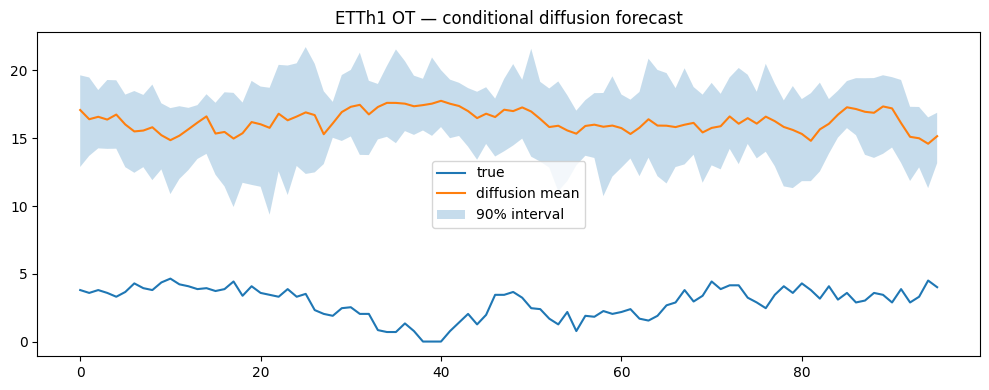

In [16]:
diffusion_metrics = {}
diffusion_samples_original = None
diffusion_truth_original = None

if RUN_DIFFUSION:
    diffusion_model = ConditionalDiffusion1D(
        in_channels=len(value_cols),
        context_d_model=F_CFG.d_model,
        context_heads=F_CFG.n_heads,
        context_layers=F_CFG.n_layers,
        hidden=D_CFG.hidden,
        n_blocks=D_CFG.n_blocks,
        timesteps=D_CFG.timesteps,
        dropout=F_CFG.dropout,
    ).to(DEVICE)

    diffusion_ckpt = ARTIFACT_DIR / "diffusion_best.pt"
    diffusion_model, diffusion_history = fit_diffusion(
        diffusion_model,
        loader(f_train_ds, D_CFG.batch_size, shuffle=True),
        loader(f_val_ds, D_CFG.batch_size),
        D_CFG.epochs, D_CFG.lr, diffusion_ckpt,
    )
    diffusion_history.to_csv(
        ARTIFACT_DIR / "diffusion_history.csv", index=False
    )
    plot_history(diffusion_history, "Conditional diffusion")

    n_eval = min(D_CFG.max_eval_windows, len(f_test_ds))
    contexts, futures = [], []
    for idx in range(n_eval):
        x, y = f_test_ds[idx]
        contexts.append(x.numpy())
        futures.append(y.numpy())

    context_tensor = torch.tensor(
        np.stack(contexts), dtype=torch.float32, device=DEVICE
    )
    future_scaled = np.stack(futures)

    samples_scaled = sample_mc_paths(
        diffusion_model, context_tensor, F_CFG.pred_len, D_CFG.n_samples
    )
    M, B, H, C = samples_scaled.shape

    diffusion_samples_original = f_scaler.inverse_transform(
        samples_scaled.reshape(-1, C)
    ).reshape(M, B, H, C)
    diffusion_truth_original = f_scaler.inverse_transform(
        future_scaled.reshape(-1, C)
    ).reshape(B, H, C)

    diffusion_metrics = probabilistic_metrics(
        diffusion_samples_original, diffusion_truth_original
    )
    diffusion_metrics["n_mc_samples"] = D_CFG.n_samples
    diffusion_metrics["n_eval_windows"] = n_eval
    print(json.dumps(diffusion_metrics, indent=2))
    save_json(diffusion_metrics, ARTIFACT_DIR / "diffusion_metrics.json")

    ot_idx = value_cols.index("OT") if "OT" in value_cols else -1
    s = diffusion_samples_original[:, 0, :, ot_idx]
    y = diffusion_truth_original[0, :, ot_idx]
    mean = s.mean(axis=0)
    q05, q95 = np.quantile(s, [0.05, 0.95], axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(y, label="true")
    plt.plot(mean, label="diffusion mean")
    plt.fill_between(
        np.arange(len(y)), q05, q95, alpha=0.25, label="90% interval"
    )
    plt.title("ETTh1 OT — conditional diffusion forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Diffusion section skipped.")

# PART 5. Anomaly Detection — PSM

정상 train window를 일부 mask한 뒤 원 signal을 복원하는 denoising reconstruction model을 사용합니다.

Hybrid score:
\[
S_t = \frac{1}{3}\left[
Z_{robust}(E_t^{rec}) +
Z_{robust}(D_t^{Mahalanobis}) +
Z_{robust}(V_t^{latent})
\right]
\]

- reconstruction error
- train-normal latent Mahalanobis distance
- latent transition velocity

각 component는 validation-normal에서 median/MAD로 calibration합니다.

In [17]:
psm_train_raw, psm_test_raw, psm_label_raw = load_psm_raw()

psm_train_values = psm_train_raw.iloc[:, 1:].to_numpy(dtype=np.float64)
psm_test_values = psm_test_raw.iloc[:, 1:].to_numpy(dtype=np.float64)

label_values = psm_label_raw.iloc[:, 1:].to_numpy()
if label_values.ndim == 2:
    psm_labels = (label_values > 0).any(axis=1).astype(np.int64)
else:
    psm_labels = (label_values > 0).astype(np.int64)

assert len(psm_test_values) == len(psm_labels)

a_split = int(len(psm_train_values) * 0.80)
a_imputer = SimpleImputer(strategy="median")
a_scaler = StandardScaler()

train_core = a_imputer.fit_transform(psm_train_values[:a_split])
a_scaler.fit(train_core)

a_train = a_scaler.transform(train_core).astype(np.float32)
a_val = a_scaler.transform(
    a_imputer.transform(psm_train_values[a_split:])
).astype(np.float32)
a_test = a_scaler.transform(
    a_imputer.transform(psm_test_values)
).astype(np.float32)

a_train_ds = AnomalyWindowDataset(
    a_train, A_CFG.win_size, A_CFG.train_step
)
a_val_ds = AnomalyWindowDataset(
    a_val, A_CFG.win_size, A_CFG.eval_step
)
a_test_ds = AnomalyWindowDataset(
    a_test, A_CFG.win_size, A_CFG.eval_step
)

a_train_loader = loader(a_train_ds, A_CFG.batch_size, shuffle=True)
a_train_eval_loader = loader(a_train_ds, A_CFG.batch_size, shuffle=False)
a_val_loader = loader(a_val_ds, A_CFG.batch_size)
a_test_loader = loader(a_test_ds, A_CFG.batch_size)

print("PSM features:", a_train.shape[1])
print("test anomaly ratio:", psm_labels.mean())

PSM/train.csv: reconstructing file:   0%|          |  0.00B / 63.6MB            

PSM/train.csv: downloading bytes:           |  0.00B            

PSM/test.csv: reconstructing file:   0%|          |  0.00B / 42.5MB            

PSM/test.csv: downloading bytes:           |  0.00B            

test_label.csv:   0%|          | 0.00/966k [00:00<?, ?B/s]

PSM features: 25
test anomaly ratio: 0.27755831559294636


{'epoch': 1, 'train_loss': 0.36270605476505785, 'val_loss': 1.1422410999380408}
{'epoch': 2, 'train_loss': 0.14726220915116459, 'val_loss': 0.6321766364077727}
{'epoch': 3, 'train_loss': 0.11145752165690963, 'val_loss': 0.5224391253931182}


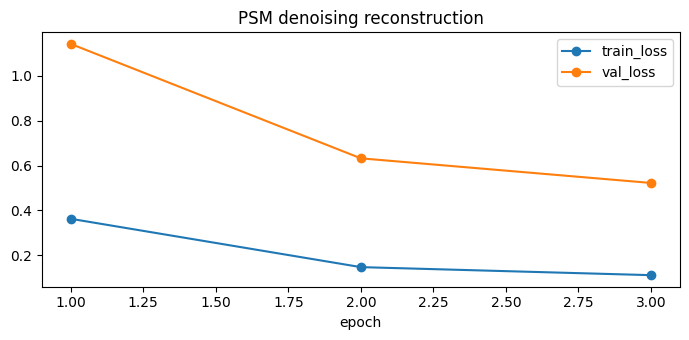

In [18]:
anomaly_model = UnifiedTSModel(
    "anomaly", a_train.shape[1],
    A_CFG.d_model, A_CFG.n_heads, A_CFG.n_layers, A_CFG.dropout
)

anomaly_ckpt = ARTIFACT_DIR / "anomaly_best.pt"
anomaly_model, anomaly_history = fit_mse_task(
    anomaly_model,
    a_train_loader,
    a_val_loader,
    A_CFG.epochs,
    A_CFG.lr,
    anomaly_ckpt,
    "anomaly",
    mask_ratio=A_CFG.mask_ratio,
)

anomaly_history.to_csv(
    ARTIFACT_DIR / "anomaly_history.csv", index=False
)
plot_history(anomaly_history, "PSM denoising reconstruction")

In [19]:
@torch.no_grad()
def extract_window_embeddings(model, data_loader):
    model.eval()
    zs, starts = [], []
    for x, s in data_loader:
        zs.append(model.encode(x.to(DEVICE)).cpu().numpy())
        starts.append(s.numpy())
    return np.concatenate(zs), np.concatenate(starts)

@torch.no_grad()
def pointwise_reconstruction_score(model, data_loader, series_length, win_size):
    model.eval()
    total = np.zeros(series_length, dtype=np.float64)
    count = np.zeros(series_length, dtype=np.float64)

    for x, starts in data_loader:
        x_dev = x.to(DEVICE)
        rec = model(x_dev)
        err = ((rec - x_dev) ** 2).mean(dim=-1).cpu().numpy()

        for e, s in zip(err, starts.numpy()):
            s = int(s)
            total[s:s+win_size] += e
            count[s:s+win_size] += 1.0

    covered = count > 0
    out = np.zeros(series_length, dtype=np.float64)
    out[covered] = total[covered] / count[covered]

    if (~covered).any():
        out[~covered] = np.median(out[covered])

    return out

def aggregate_window_score(starts, scores, series_length, win_size):
    total = np.zeros(series_length, dtype=np.float64)
    count = np.zeros(series_length, dtype=np.float64)

    for s, score in zip(starts.astype(int), scores):
        e = min(s + win_size, series_length)
        total[s:e] += float(score)
        count[s:e] += 1.0

    covered = count > 0
    out = np.zeros_like(total)
    out[covered] = total[covered] / count[covered]

    if (~covered).any():
        out[~covered] = np.median(out[covered])

    return out

def robust_loc_scale(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float64)
    center = np.median(x)
    mad = np.median(np.abs(x - center))
    return center, max(1.4826 * mad, eps)

def latent_velocity(z):
    out = np.zeros(len(z), dtype=np.float64)
    if len(z) > 1:
        out[1:] = np.linalg.norm(np.diff(z, axis=0), axis=1)
        out[0] = out[1]
    return out

def mahalanobis_score(z, mean, precision):
    d = z - mean[None, :]
    q = np.einsum("bi,ij,bj->b", d, precision, d)
    return np.sqrt(np.maximum(q, 0.0))

threshold: 2.8381056978047807
{
  "precision": 0.8131067961165048,
  "recall": 0.013740207538657151,
  "f1": 0.02702375670552172,
  "AUROC": 0.8267628414623287,
  "AUPRC": 0.6424918831928808
}


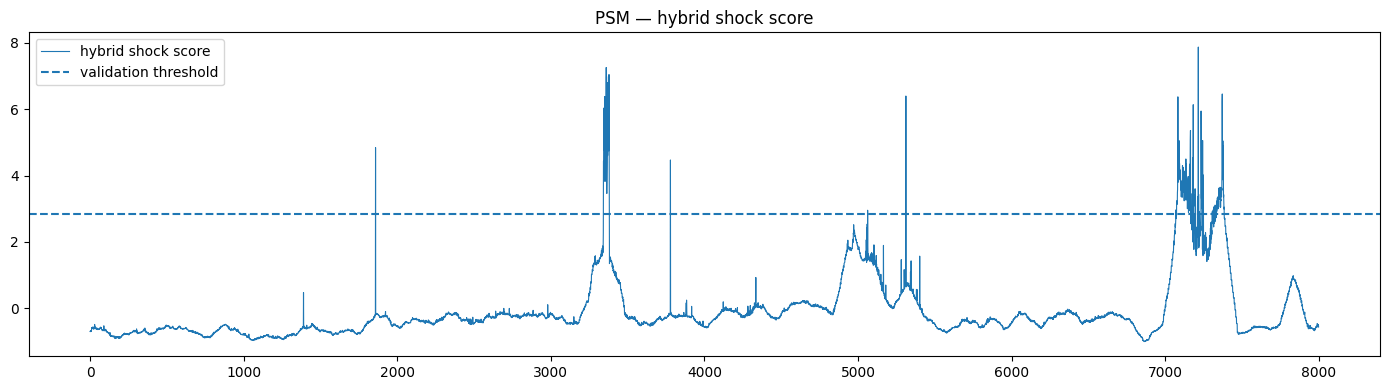

In [20]:
def build_hybrid_shock_score(
    model, train_loader, val_loader, test_loader,
    train_length, val_length, test_length, win_size
):
    va_rec = pointwise_reconstruction_score(
        model, val_loader, val_length, win_size
    )
    te_rec = pointwise_reconstruction_score(
        model, test_loader, test_length, win_size
    )

    z_tr, s_tr = extract_window_embeddings(model, train_loader)
    z_va, s_va = extract_window_embeddings(model, val_loader)
    z_te, s_te = extract_window_embeddings(model, test_loader)

    oas = OAS(store_precision=True).fit(z_tr)

    va_maha = mahalanobis_score(z_va, oas.location_, oas.precision_)
    te_maha = mahalanobis_score(z_te, oas.location_, oas.precision_)

    va_vel = latent_velocity(z_va)
    te_vel = latent_velocity(z_te)

    va_maha_p = aggregate_window_score(s_va, va_maha, val_length, win_size)
    te_maha_p = aggregate_window_score(s_te, te_maha, test_length, win_size)
    va_vel_p = aggregate_window_score(s_va, va_vel, val_length, win_size)
    te_vel_p = aggregate_window_score(s_te, te_vel, test_length, win_size)

    val_components = {
        "reconstruction": va_rec,
        "mahalanobis": va_maha_p,
        "latent_velocity": va_vel_p,
    }
    test_components = {
        "reconstruction": te_rec,
        "mahalanobis": te_maha_p,
        "latent_velocity": te_vel_p,
    }

    val_hybrid = np.zeros(val_length, dtype=np.float64)
    test_hybrid = np.zeros(test_length, dtype=np.float64)
    calibration = {}

    for name in val_components:
        center, scale = robust_loc_scale(val_components[name])
        calibration[name] = {"center": center, "scale": scale}
        val_hybrid += (val_components[name] - center) / scale
        test_hybrid += (test_components[name] - center) / scale

    val_hybrid /= len(val_components)
    test_hybrid /= len(test_components)

    return val_hybrid, test_hybrid, {
        "train_embeddings": z_tr,
        "val_embeddings": z_va,
        "test_embeddings": z_te,
        "val_components": val_components,
        "test_components": test_components,
        "calibration": calibration,
    }

val_shock_score, test_shock_score, anomaly_diag = build_hybrid_shock_score(
    anomaly_model,
    a_train_eval_loader,
    a_val_loader,
    a_test_loader,
    len(a_train),
    len(a_val),
    len(a_test),
    A_CFG.win_size,
)

anomaly_threshold = float(
    np.quantile(val_shock_score, A_CFG.threshold_quantile)
)
anomaly_pred = (test_shock_score > anomaly_threshold).astype(np.int64)

anomaly_point_metrics = {
    "precision": precision_score(psm_labels, anomaly_pred, zero_division=0),
    "recall": recall_score(psm_labels, anomaly_pred, zero_division=0),
    "f1": f1_score(psm_labels, anomaly_pred, zero_division=0),
    "AUROC": roc_auc_score(psm_labels, test_shock_score),
    "AUPRC": average_precision_score(psm_labels, test_shock_score),
}

print("threshold:", anomaly_threshold)
print(json.dumps(anomaly_point_metrics, indent=2))
save_json(
    anomaly_point_metrics,
    ARTIFACT_DIR / "anomaly_point_metrics.json",
)

component_df = pd.DataFrame({
    "reconstruction": anomaly_diag["test_components"]["reconstruction"],
    "mahalanobis": anomaly_diag["test_components"]["mahalanobis"],
    "latent_velocity": anomaly_diag["test_components"]["latent_velocity"],
    "hybrid": test_shock_score,
    "label": psm_labels,
})
component_df.to_csv(
    ARTIFACT_DIR / "anomaly_components.csv", index=False
)

plt.figure(figsize=(14, 4))
show_n = min(8000, len(test_shock_score))
plt.plot(test_shock_score[:show_n], label="hybrid shock score", linewidth=0.8)
plt.axhline(anomaly_threshold, linestyle="--", label="validation threshold")
plt.title("PSM — hybrid shock score")
plt.legend()
plt.tight_layout()
plt.show()

# PART 6. Ragged Event Analysis — Awkward Array

연속된 anomaly timestamp를 하나의 variable-length episode로 묶어 Awkward Array에 저장합니다.

각 event:
- duration
- mean score
- peak score
- predicted points
- detection 여부

In [21]:
def contiguous_segments_numpy(y):
    y = np.asarray(y).astype(np.int64)
    starts, ends = [], []
    i, n = 0, len(y)

    while i < n:
        if y[i] == 1:
            s = i
            while i < n and y[i] == 1:
                i += 1
            starts.append(s)
            ends.append(i)
        else:
            i += 1

    return (
        np.asarray(starts, dtype=np.int64),
        np.asarray(ends, dtype=np.int64),
    )

def build_awkward_events(y_true, score, y_pred=None):
    starts, ends = contiguous_segments_numpy(y_true)
    if y_pred is None:
        y_pred = np.zeros_like(y_true)

    indices, scores, preds = [], [], []
    for s, e in zip(starts, ends):
        indices.append(np.arange(s, e).tolist())
        scores.append(np.asarray(score[s:e], dtype=float).tolist())
        preds.append(np.asarray(y_pred[s:e], dtype=int).tolist())

    return ak.Array({
        "indices": indices,
        "scores": scores,
        "predictions": preds,
    })

true_events = build_awkward_events(
    psm_labels, test_shock_score, anomaly_pred
)

event_duration = ak.num(true_events.indices, axis=1)
event_peak = ak.max(true_events.scores, axis=1)
event_mean = ak.mean(true_events.scores, axis=1)
event_detected = ak.sum(true_events.predictions, axis=1) > 0

event_table = pd.DataFrame({
    "event_id": np.arange(len(true_events)),
    "duration": ak.to_numpy(event_duration),
    "mean_score": ak.to_numpy(event_mean),
    "peak_score": ak.to_numpy(event_peak),
    "detected": ak.to_numpy(event_detected).astype(int),
})

display(event_table.head(20))
event_table.to_csv(
    ARTIFACT_DIR / "ragged_event_table.csv", index=False
)

,event_id,duration,mean_score,peak_score,detected
0,0,3,-0.613104,-0.526453,0
1,1,1,-0.262256,-0.262256,0
2,2,3,-0.178342,-0.172353,0
3,3,191,2.021126,7.256105,1
4,4,3,-0.227822,-0.225939,0
5,5,4,-0.268308,-0.250278,0
6,6,281,1.502080,2.954966,1
7,7,1,0.462538,0.462538,0
8,8,3,2.602784,6.396608,1
9,9,331,3.032346,7.871606,1


In [22]:
def event_level_metrics(y_true, y_pred):
    true_s, true_e = contiguous_segments_numpy(y_true)
    pred_s, pred_e = contiguous_segments_numpy(y_pred)

    true_hit = 0
    for ts, te in zip(true_s, true_e):
        hit = any(max(ts, ps) < min(te, pe) for ps, pe in zip(pred_s, pred_e))
        true_hit += int(hit)

    pred_hit = 0
    for ps, pe in zip(pred_s, pred_e):
        hit = any(max(ts, ps) < min(te, pe) for ts, te in zip(true_s, true_e))
        pred_hit += int(hit)

    event_recall = true_hit / max(len(true_s), 1)
    event_precision = pred_hit / max(len(pred_s), 1)
    event_f1 = (
        2 * event_precision * event_recall
        / max(event_precision + event_recall, 1e-12)
    )

    return {
        "n_true_events": int(len(true_s)),
        "n_pred_events": int(len(pred_s)),
        "event_precision": float(event_precision),
        "event_recall": float(event_recall),
        "event_f1": float(event_f1),
    }

event_metrics = event_level_metrics(psm_labels, anomaly_pred)
print(json.dumps(event_metrics, indent=2))
save_json(event_metrics, ARTIFACT_DIR / "event_metrics.json")

{
  "n_true_events": 72,
  "n_pred_events": 101,
  "event_precision": 0.8613861386138614,
  "event_recall": 0.4861111111111111,
  "event_f1": 0.6214919889784672
}


# PART 7. High-performance Evaluation — Python vs Numba PA%K

PA%K reference 구현과 Numba JIT 구현을 모두 만들고:
1. 모든 K에서 exact equivalence
2. warm-up 이후 runtime benchmark
3. PA%K curve
를 확인합니다.

In [23]:
def point_adjust_at_k_python(y_true, y_pred, k_percent):
    y_true = np.asarray(y_true, dtype=np.int64)
    out = np.asarray(y_pred, dtype=np.int64).copy()
    threshold = k_percent / 100.0

    i, n = 0, len(y_true)
    while i < n:
        if y_true[i] == 1:
            s = i
            while i < n and y_true[i] == 1:
                i += 1
            e = i
            detected = float(out[s:e].sum()) / (e - s)
            if detected > threshold:
                out[s:e] = 1
        else:
            i += 1
    return out

@njit
def point_adjust_at_k_numba(y_true, y_pred, k_percent):
    out = y_pred.copy()
    threshold = k_percent / 100.0
    i = 0
    n = len(y_true)

    while i < n:
        if y_true[i] == 1:
            s = i
            while i < n and y_true[i] == 1:
                i += 1
            e = i

            detected_count = 0
            for j in range(s, e):
                detected_count += out[j]

            detected = detected_count / (e - s)
            if detected > threshold:
                for j in range(s, e):
                    out[j] = 1
        else:
            i += 1

    return out

_ = point_adjust_at_k_numba(
    psm_labels[:100].astype(np.int64),
    anomaly_pred[:100].astype(np.int64),
    10.0,
)

for k in range(0, 101, 5):
    py = point_adjust_at_k_python(psm_labels, anomaly_pred, k)
    nbv = point_adjust_at_k_numba(
        psm_labels.astype(np.int64),
        anomaly_pred.astype(np.int64),
        float(k),
    )
    assert np.array_equal(py, nbv)

print("✓ Python/Numba PA%K equivalence passed")

✓ Python/Numba PA%K equivalence passed


,K,precision,recall,f1
0,0,0.996187,0.825151,0.902638
1,10,0.901408,0.028875,0.055957
2,20,0.865854,0.020385,0.039832
3,30,0.865149,0.020262,0.039596
4,40,0.863233,0.019934,0.038967
5,50,0.863233,0.019934,0.038967
6,60,0.814458,0.013863,0.027262
7,70,0.814458,0.013863,0.027262
8,80,0.814458,0.013863,0.027262
9,90,0.813107,0.013740,0.027024


PA%K area: 0.07869618065372187
{
  "repeats": 50,
  "python_total_sec": 0.7232642720000513,
  "numba_total_sec": 0.010237458999995397,
  "speedup_python_over_numba": 70.64880767780134
}


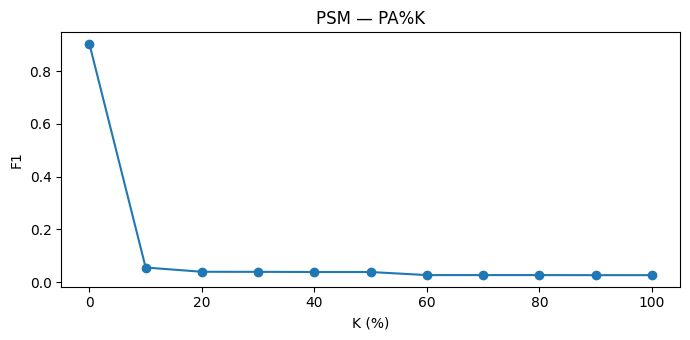

In [24]:
def pak_curve(y_true, y_pred):
    rows = []
    for k in range(0, 101, 10):
        adj = point_adjust_at_k_numba(
            np.asarray(y_true, dtype=np.int64),
            np.asarray(y_pred, dtype=np.int64),
            float(k),
        )
        rows.append({
            "K": k,
            "precision": precision_score(y_true, adj, zero_division=0),
            "recall": recall_score(y_true, adj, zero_division=0),
            "f1": f1_score(y_true, adj, zero_division=0),
        })
    return pd.DataFrame(rows)

pa_curve = pak_curve(psm_labels, anomaly_pred)
display(pa_curve)

xk = pa_curve["K"].to_numpy()
yf = pa_curve["f1"].to_numpy()
if hasattr(np, "trapezoid"):
    pak_auc = float(np.trapezoid(yf, xk) / 100.0)
else:
    pak_auc = float(np.trapz(yf, xk) / 100.0)

def benchmark_pak(y_true, y_pred, repeats=None):
    repeats = (50 if QUICK_RUN else 500) if repeats is None else repeats
    yt = np.asarray(y_true, dtype=np.int64)
    yp = np.asarray(y_pred, dtype=np.int64)

    t0 = time.perf_counter()
    for _ in range(repeats):
        point_adjust_at_k_python(yt, yp, 20.0)
    py_sec = time.perf_counter() - t0

    t0 = time.perf_counter()
    for _ in range(repeats):
        point_adjust_at_k_numba(yt, yp, 20.0)
    nb_sec = time.perf_counter() - t0

    return {
        "repeats": repeats,
        "python_total_sec": py_sec,
        "numba_total_sec": nb_sec,
        "speedup_python_over_numba": py_sec / max(nb_sec, 1e-12),
    }

pak_runtime = benchmark_pak(psm_labels, anomaly_pred)
print("PA%K area:", pak_auc)
print(json.dumps(pak_runtime, indent=2))

pa_curve.to_csv(ARTIFACT_DIR / "pa_k_curve.csv", index=False)
save_json(pak_runtime, ARTIFACT_DIR / "pa_k_runtime.json")

plt.figure(figsize=(7, 3.5))
plt.plot(pa_curve["K"], pa_curve["f1"], marker="o")
plt.xlabel("K (%)")
plt.ylabel("F1")
plt.title("PSM — PA%K")
plt.tight_layout()
plt.show()

# PART 8. Classification — Libras

official train 내부에서 stratified validation을 만들고, train-only channel scaling 후
Unified Temporal Encoder + attention pooling classifier를 학습합니다.

In [25]:
X_off_train, y_off_train, X_test_raw, y_test_raw = load_libras_raw()

label_encoder = LabelEncoder()
label_encoder.fit(y_off_train)
y_all = label_encoder.transform(y_off_train)
y_test = label_encoder.transform(y_test_raw)

indices = np.arange(len(y_all))
tr_idx, va_idx = train_test_split(
    indices, test_size=0.20, random_state=SEED, stratify=y_all
)

X_all = np.asarray(X_off_train, dtype=np.float64)
X_test_arr = np.asarray(X_test_raw, dtype=np.float64)

def fit_channel_scaler(X):
    C = X.shape[1]
    flat = X.transpose(0, 2, 1).reshape(-1, C)
    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()
    flat_imp = imp.fit_transform(flat)
    sc.fit(flat_imp)
    return imp, sc

def transform_channels(X, imp, sc):
    N, C, L = X.shape
    flat = X.transpose(0, 2, 1).reshape(-1, C)
    flat = sc.transform(imp.transform(flat))
    return flat.reshape(N, L, C).transpose(0, 2, 1).astype(np.float32)

c_imputer, c_scaler = fit_channel_scaler(X_all[tr_idx])

X_train = transform_channels(X_all[tr_idx], c_imputer, c_scaler)
X_val = transform_channels(X_all[va_idx], c_imputer, c_scaler)
X_test = transform_channels(X_test_arr, c_imputer, c_scaler)

y_train = y_all[tr_idx]
y_val = y_all[va_idx]

c_train_ds = ClassificationDataset(X_train, y_train)
c_val_ds = ClassificationDataset(X_val, y_val)
c_test_ds = ClassificationDataset(X_test, y_test)

c_train_loader = loader(c_train_ds, C_CFG.batch_size, shuffle=True)
c_val_loader = loader(c_val_ds, C_CFG.batch_size)
c_test_loader = loader(c_test_ds, C_CFG.batch_size)

print("train/val/test:", len(c_train_ds), len(c_val_ds), len(c_test_ds))
print("n_classes:", len(label_encoder.classes_))

train/val/test: 144 36 180
n_classes: 15


{'epoch': 1, 'train_loss': 2.724267053604126, 'train_acc': 0.0625, 'val_loss': 2.63081955909729, 'val_acc': 0.19444444444444445}
{'epoch': 2, 'train_loss': 2.6397318840026855, 'train_acc': 0.13194444444444445, 'val_loss': 2.58305561542511, 'val_acc': 0.2222222222222222}
{'epoch': 3, 'train_loss': 2.5646693229675295, 'train_acc': 0.2013888888888889, 'val_loss': 2.4700887203216553, 'val_acc': 0.19444444444444445}
{'epoch': 4, 'train_loss': 2.4730249404907227, 'train_acc': 0.25, 'val_loss': 2.3231793642044067, 'val_acc': 0.3333333333333333}
{'epoch': 5, 'train_loss': 2.357603120803833, 'train_acc': 0.3263888888888889, 'val_loss': 2.1865559816360474, 'val_acc': 0.3055555555555556}
{'epoch': 6, 'train_loss': 2.2711804866790772, 'train_acc': 0.3472222222222222, 'val_loss': 2.1126180291175842, 'val_acc': 0.3333333333333333}
{'epoch': 7, 'train_loss': 2.1364443778991697, 'train_acc': 0.4097222222222222, 'val_loss': 2.002234160900116, 'val_acc': 0.3611111111111111}
{'epoch': 8, 'train_loss': 2.

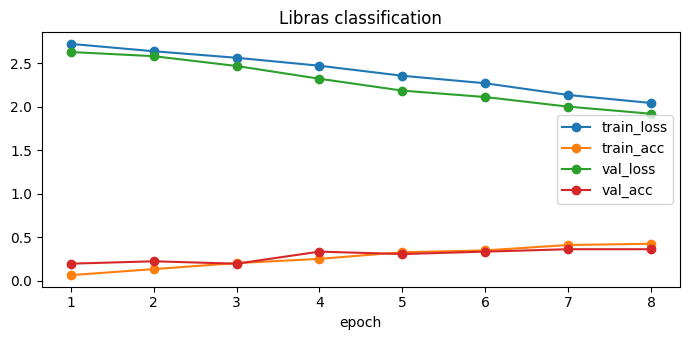

In [26]:
classification_model = UnifiedTSModel(
    "classification", X_train.shape[1],
    C_CFG.d_model, C_CFG.n_heads, C_CFG.n_layers, C_CFG.dropout,
    n_classes=len(label_encoder.classes_)
)

classification_ckpt = ARTIFACT_DIR / "classification_best.pt"
classification_model, classification_history = fit_classifier(
    classification_model,
    c_train_loader,
    c_val_loader,
    C_CFG.epochs,
    C_CFG.lr,
    classification_ckpt,
)

classification_history.to_csv(
    ARTIFACT_DIR / "classification_history.csv", index=False
)
plot_history(classification_history, "Libras classification")

{
  "accuracy": 0.4,
  "macro_f1": 0.35444253192420283,
  "weighted_f1": 0.3544425319242028,
  "majority_accuracy": 0.06666666666666667
}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        12
          10       0.25      0.17      0.20        12
          11       0.26      0.50      0.34        12
          12       0.53      0.67      0.59        12
          13       0.00      0.00      0.00        12
          14       0.62      0.67      0.64        12
          15       0.50      0.17      0.25        12
           2       0.40      0.33      0.36        12
           3       0.00      0.00      0.00        12
           4       0.42      0.83      0.56        12
           5       0.70      0.58      0.64        12
           6       0.46      0.50      0.48        12
           7       0.44      0.33      0.38        12
           8       0.23      0.75      0.35        12
           9       0.55      0.50      0.52        

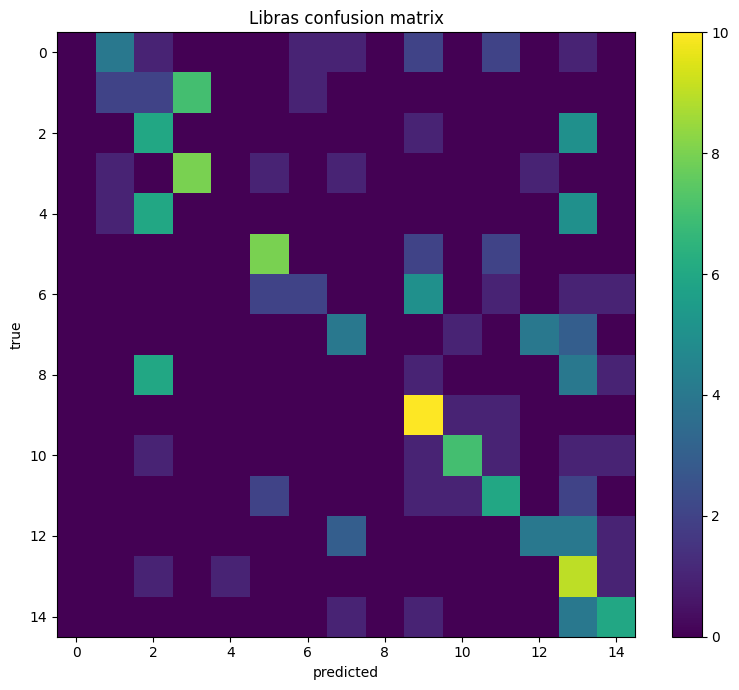

In [27]:
@torch.no_grad()
def classifier_predict(model, data_loader):
    model.eval()
    pred, true = [], []
    for x, y in data_loader:
        logits = model(x.to(DEVICE))
        pred.append(logits.argmax(-1).cpu().numpy())
        true.append(y.numpy())
    return np.concatenate(pred), np.concatenate(true)

c_pred, c_true = classifier_predict(classification_model, c_test_loader)
majority_class = np.bincount(y_train).argmax()
majority_pred = np.full_like(c_true, majority_class)

classification_metrics = {
    "accuracy": accuracy_score(c_true, c_pred),
    "macro_f1": f1_score(c_true, c_pred, average="macro"),
    "weighted_f1": f1_score(c_true, c_pred, average="weighted"),
    "majority_accuracy": accuracy_score(c_true, majority_pred),
}

print(json.dumps(classification_metrics, indent=2))
print(classification_report(
    c_true, c_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=[str(x) for x in label_encoder.classes_],
    zero_division=0,
))
save_json(
    classification_metrics,
    ARTIFACT_DIR / "classification_metrics.json",
)

cm = confusion_matrix(
    c_true, c_pred,
    labels=np.arange(len(label_encoder.classes_))
)
plt.figure(figsize=(8, 7))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.title("Libras confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.tight_layout()
plt.show()

# PART 9. Latent Representation Analysis

- train embedding에만 PCA fit
- test embedding은 transform만 수행
- feature perturbation으로 latent sensitivity 계산
- forecasting trajectory / anomaly regime / classification class separation 확인

PCA/perturbation은 model sensitivity이며 인과효과가 아닙니다.

In [28]:
@torch.no_grad()
def embeddings_from_loader(model, data_loader):
    model.eval()
    zs, aux = [], []
    for x, y in data_loader:
        zs.append(model.encode(x.to(DEVICE)).cpu().numpy())
        aux.append(y.numpy())
    return np.concatenate(zs), np.concatenate(aux)

def fit_train_pca(z_train, n_components=2):
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(z_train)
    return pca

@torch.no_grad()
def feature_latent_sensitivity(model, X, feature_names, pca=None):
    X = X.to(DEVICE)
    base_z = model.encode(X).detach().cpu().numpy()
    base_pc = pca.transform(base_z) if pca is not None else None

    rows = []
    for j, name in enumerate(feature_names):
        x_occ = X.clone()
        x_occ[:, :, j] = 0.0
        occ_z = model.encode(x_occ).detach().cpu().numpy()

        row = {
            "feature": name,
            "latent_L2_influence": float(
                np.linalg.norm(occ_z - base_z, axis=1).mean()
            ),
        }

        if pca is not None:
            occ_pc = pca.transform(occ_z)
            delta = np.abs(occ_pc - base_pc)
            row["PC1_influence"] = float(delta[:, 0].mean())
            row["PC2_influence"] = float(delta[:, 1].mean())

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        "latent_L2_influence", ascending=False
    )

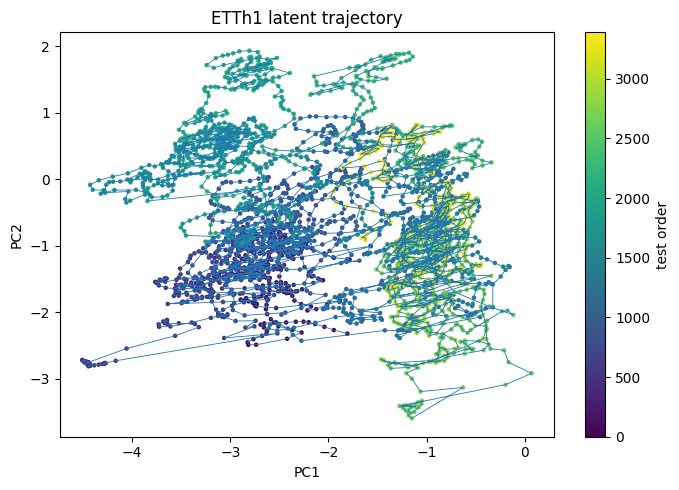

,feature,latent_L2_influence,PC1_influence,PC2_influence
6,OT,3.757559,1.145348,0.926378
2,MUFL,2.649282,0.278584,0.130769
4,LUFL,2.286381,0.645747,0.764778
0,HUFL,1.656266,0.411497,0.121167
1,HULL,0.895467,0.299675,0.115970
3,MULL,0.872030,0.442821,0.173563
5,LULL,0.484764,0.048796,0.046261


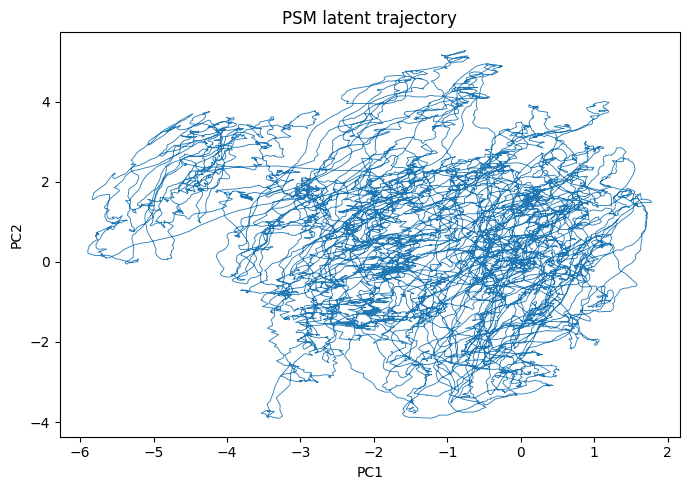

In [29]:
latent_results = {}

if RUN_LATENT_ANALYSIS:
    # Forecast
    f_train_eval = loader(f_train_ds, F_CFG.batch_size, shuffle=False)
    f_test_eval = loader(f_test_ds, F_CFG.batch_size, shuffle=False)

    zf_train, _ = embeddings_from_loader(forecast_model, f_train_eval)
    zf_test, _ = embeddings_from_loader(forecast_model, f_test_eval)
    pca_f = fit_train_pca(zf_train, 2)
    pcf = pca_f.transform(zf_test)

    plt.figure(figsize=(7, 5))
    plt.plot(pcf[:, 0], pcf[:, 1], linewidth=0.6)
    sc = plt.scatter(pcf[:, 0], pcf[:, 1], s=5, c=np.arange(len(pcf)))
    plt.colorbar(sc, label="test order")
    plt.title("ETTh1 latent trajectory")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    xb = []
    for b, (x, _) in enumerate(f_test_eval):
        xb.append(x)
        if b >= (4 if QUICK_RUN else 20):
            break

    f_influence = feature_latent_sensitivity(
        forecast_model, torch.cat(xb), value_cols, pca=pca_f
    )
    display(f_influence)
    f_influence.to_csv(
        ARTIFACT_DIR / "forecast_latent_feature_influence.csv", index=False
    )

    # Anomaly
    za_train = anomaly_diag["train_embeddings"]
    za_test = anomaly_diag["test_embeddings"]
    pca_a = fit_train_pca(za_train, 2)
    pca_test = pca_a.transform(za_test)

    plt.figure(figsize=(7, 5))
    plt.plot(pca_test[:, 0], pca_test[:, 1], linewidth=0.6)
    plt.title("PSM latent trajectory")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    latent_results["forecast_pc_variance"] = pca_f.explained_variance_ratio_.tolist()
    latent_results["anomaly_pc_variance"] = pca_a.explained_variance_ratio_.tolist()

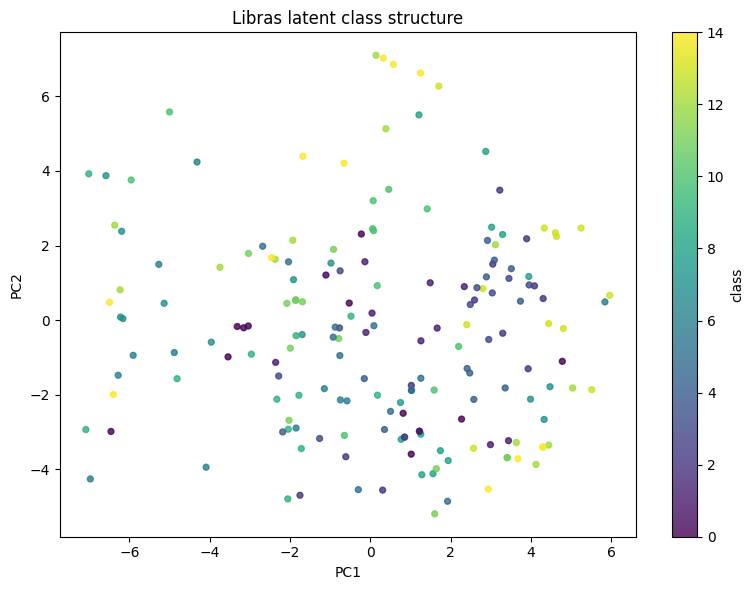

{
  "forecast_pc_variance": [
    0.39570820331573486,
    0.15827250480651855
  ],
  "anomaly_pc_variance": [
    0.24567386507987976,
    0.16530922055244446
  ],
  "classification_silhouette": -0.08072531223297119,
  "classification_centroid_accuracy": 0.4111111111111111,
  "classification_pc_variance": [
    0.411947101354599,
    0.2836422026157379
  ]
}


In [30]:
if RUN_LATENT_ANALYSIS:
    # Classification
    c_train_eval = loader(c_train_ds, C_CFG.batch_size, shuffle=False)
    c_test_eval = loader(c_test_ds, C_CFG.batch_size, shuffle=False)

    zc_train, yc_train = embeddings_from_loader(classification_model, c_train_eval)
    zc_test, yc_test = embeddings_from_loader(classification_model, c_test_eval)

    pca_c = fit_train_pca(zc_train, 2)
    pcc = pca_c.transform(zc_test)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(pcc[:, 0], pcc[:, 1], c=yc_test, s=18, alpha=0.8)
    plt.colorbar(sc, label="class")
    plt.title("Libras latent class structure")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    sil = silhouette_score(zc_test, yc_test)

    classes = np.unique(yc_train)
    centroids = np.stack([
        zc_train[yc_train == k].mean(axis=0) for k in classes
    ])
    dist2 = ((zc_test[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=-1)
    centroid_pred = classes[dist2.argmin(axis=1)]
    centroid_acc = accuracy_score(yc_test, centroid_pred)

    latent_results.update({
        "classification_silhouette": float(sil),
        "classification_centroid_accuracy": float(centroid_acc),
        "classification_pc_variance": pca_c.explained_variance_ratio_.tolist(),
    })

    print(json.dumps(latent_results, indent=2))
    save_json(latent_results, ARTIFACT_DIR / "latent_results.json")

# PART 10. Stability — Multi-seed & Representation Consistency

Shock score:
- Pearson correlation
- top 1% timestamp Jaccard

Representation:
- Linear CKA

raw latent 좌표는 seed에 따라 회전할 수 있으므로 CKA를 사용합니다.

In [31]:
def top_fraction_jaccard(a, b, frac=0.01):
    a = np.asarray(a)
    b = np.asarray(b)
    k = max(1, int(round(len(a) * frac)))
    ia = set(np.argpartition(a, -k)[-k:])
    ib = set(np.argpartition(b, -k)[-k:])
    return len(ia & ib) / max(len(ia | ib), 1)

def linear_cka(X, Y):
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    xy = X.T @ Y
    xx = X.T @ X
    yy = Y.T @ Y

    num = np.sum(xy * xy)
    den = math.sqrt(np.sum(xx * xx) * np.sum(yy * yy))
    return float(num / max(den, 1e-12))

In [32]:
stability_metrics = {}

if RUN_STABILITY:
    seed_everything(SEED + 101)

    anomaly_model_seed2 = UnifiedTSModel(
        "anomaly", a_train.shape[1],
        A_CFG.d_model, A_CFG.n_heads, A_CFG.n_layers, A_CFG.dropout
    )
    ckpt2 = ARTIFACT_DIR / "anomaly_seed2_best.pt"

    anomaly_model_seed2, _ = fit_mse_task(
        anomaly_model_seed2,
        loader(a_train_ds, A_CFG.batch_size, shuffle=True),
        a_val_loader,
        A_CFG.epochs,
        A_CFG.lr,
        ckpt2,
        "anomaly",
        mask_ratio=A_CFG.mask_ratio,
    )

    _, shock2, diag2 = build_hybrid_shock_score(
        anomaly_model_seed2,
        a_train_eval_loader,
        a_val_loader,
        a_test_loader,
        len(a_train),
        len(a_val),
        len(a_test),
        A_CFG.win_size,
    )

    stability_metrics = {
        "shock_score_pearson": float(
            np.corrcoef(test_shock_score, shock2)[0, 1]
        ),
        "top1pct_jaccard": top_fraction_jaccard(
            test_shock_score, shock2, 0.01
        ),
        "representation_linear_CKA": linear_cka(
            anomaly_diag["test_embeddings"],
            diag2["test_embeddings"],
        ),
    }

    print(json.dumps(stability_metrics, indent=2))
    save_json(
        stability_metrics,
        ARTIFACT_DIR / "stability_metrics.json",
    )
    seed_everything(SEED)
else:
    print("Stability retraining skipped. Set RUN_STABILITY=True.")

Stability retraining skipped. Set RUN_STABILITY=True.


# PART 11. Real Financial Market Extension

Assets:
- KOSPI
- USD/KRW
- S&P500
- VIX
- WTI
- Gold
- US10Y

설계:
- daily log return
- train 2015–2018
- validation 2019
- OOS test 2020 이후
- PART 5 hybrid shock model 재사용
- PART 6 ragged episode representation 재사용

이 score는 representation regime shift 탐색용이며 인과관계를 증명하지 않습니다.

In [33]:
def run_market_case_study():
    import yfinance as yf

    symbol_map = {
        "KOSPI": "^KS11",
        "USD_KRW": "KRW=X",
        "SP500": "^GSPC",
        "VIX": "^VIX",
        "WTI": "CL=F",
        "GOLD": "GC=F",
        "US10Y": "^TNX",
    }

    raw = yf.download(
        list(symbol_map.values()),
        start="2015-01-01",
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if not isinstance(raw.columns, pd.MultiIndex):
        raise RuntimeError("Unexpected yfinance column layout")

    prices = raw["Close"].copy()
    prices = prices.rename(columns={v: k for k, v in symbol_map.items()})
    prices = prices[list(symbol_map)].dropna(how="any")
    returns = np.log(prices).diff().dropna()

    train_mask = returns.index < "2019-01-01"
    val_mask = (
        (returns.index >= "2019-01-01")
        & (returns.index < "2020-01-01")
    )
    test_mask = returns.index >= "2020-01-01"

    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()
    tr0 = imp.fit_transform(returns.loc[train_mask])
    sc.fit(tr0)

    tr = sc.transform(tr0).astype(np.float32)
    va = sc.transform(imp.transform(returns.loc[val_mask])).astype(np.float32)
    te = sc.transform(imp.transform(returns.loc[test_mask])).astype(np.float32)

    win = 60
    step = 5 if QUICK_RUN else 1

    tr_ds = AnomalyWindowDataset(tr, win, step)
    va_ds = AnomalyWindowDataset(va, win, step)
    te_ds = AnomalyWindowDataset(te, win, step)

    tr_loader = loader(tr_ds, 64, shuffle=True)
    tr_eval = loader(tr_ds, 64, shuffle=False)
    va_loader = loader(va_ds, 64)
    te_loader = loader(te_ds, 64)

    model = UnifiedTSModel("anomaly", tr.shape[1], 64, 4, 2, 0.1)
    ckpt = ARTIFACT_DIR / "market_shock_model.pt"

    model, hist = fit_mse_task(
        model, tr_loader, va_loader,
        3 if QUICK_RUN else 15,
        1e-3, ckpt, "anomaly", mask_ratio=0.20
    )

    val_score, test_score, diag = build_hybrid_shock_score(
        model, tr_eval, va_loader, te_loader,
        len(tr), len(va), len(te), win
    )
    threshold = float(np.quantile(val_score, 0.995))
    flag = (test_score > threshold).astype(np.int64)

    test_dates = returns.loc[test_mask].index
    score_df = pd.DataFrame({
        "date": test_dates,
        "shock_score": test_score,
        "shock_flag": flag,
    })

    market_events = build_awkward_events(flag, test_score, flag)

    pca = fit_train_pca(diag["train_embeddings"], 2)
    pc = pca.transform(diag["test_embeddings"])

    plt.figure(figsize=(7, 5))
    plt.plot(pc[:, 0], pc[:, 1], linewidth=0.7)
    plt.title("Market latent trajectory — OOS")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    kospi = prices.loc[test_dates, "KOSPI"]
    shock_dates = test_dates[flag == 1]

    plt.figure(figsize=(14, 4))
    plt.plot(kospi.index, kospi.values, label="KOSPI")
    if len(shock_dates):
        plt.scatter(
            shock_dates,
            kospi.loc[shock_dates].values,
            s=12,
            label="latent shock",
        )
    plt.title("KOSPI with OOS latent-shock flags")
    plt.legend()
    plt.tight_layout()
    plt.show()

    score_df.to_csv(
        ARTIFACT_DIR / "market_shock_scores.csv", index=False
    )
    hist.to_csv(
        ARTIFACT_DIR / "market_history.csv", index=False
    )

    print("n ragged shock episodes:", len(market_events))
    display(score_df.nlargest(20, "shock_score"))

    return {
        "scores": score_df,
        "diag": diag,
        "events": market_events,
    }

market_result = None
if RUN_MARKET_CASE_STUDY:
    market_result = run_market_case_study()
else:
    print("Market extension skipped. Set RUN_MARKET_CASE_STUDY=True.")

Market extension skipped. Set RUN_MARKET_CASE_STUDY=True.


# PART 12. Final Benchmark Dashboard

각 task의 metric을 한 표로 모읍니다.
서로 다른 metric 숫자를 서로 직접 비교하지 않고 각 task의 baseline/target과 비교합니다.

In [34]:
dashboard_rows = [
    {
        "part": "P3 Deterministic Forecast",
        "metric": "OT RMSE",
        "model": forecast_metrics["model_OT"]["RMSE"],
        "baseline": forecast_metrics["persistence_OT"]["RMSE"],
        "better": "lower",
    },
    {
        "part": "P5 PSM Anomaly",
        "metric": "AUPRC",
        "model": anomaly_point_metrics["AUPRC"],
        "baseline": np.nan,
        "better": "higher",
    },
    {
        "part": "P6 Ragged Events",
        "metric": "Event F1",
        "model": event_metrics["event_f1"],
        "baseline": np.nan,
        "better": "higher",
    },
    {
        "part": "P7 PA%K",
        "metric": "PAK F1 Area",
        "model": pak_auc,
        "baseline": anomaly_point_metrics["f1"],
        "better": "higher",
    },
    {
        "part": "P8 Classification",
        "metric": "Accuracy",
        "model": classification_metrics["accuracy"],
        "baseline": classification_metrics["majority_accuracy"],
        "better": "higher",
    },
]

if RUN_DIFFUSION and diffusion_metrics:
    dashboard_rows.extend([
        {
            "part": "P4 Diffusion Forecast",
            "metric": "Empirical CRPS",
            "model": diffusion_metrics["CRPS_empirical"],
            "baseline": np.nan,
            "better": "lower",
        },
        {
            "part": "P4 Diffusion Forecast",
            "metric": "90% Coverage",
            "model": diffusion_metrics["coverage_90"],
            "baseline": 0.90,
            "better": "closer to target",
        },
    ])

dashboard = pd.DataFrame(dashboard_rows)
display(dashboard)
dashboard.to_csv(
    ARTIFACT_DIR / "final_dashboard.csv", index=False
)

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(" -", p.name)

,part,metric,model,baseline,better
0,P3 Deterministic Forecast,OT RMSE,3.666817,3.030436,lower
1,P5 PSM Anomaly,AUPRC,0.642492,NaN,higher
2,P6 Ragged Events,Event F1,0.621492,NaN,higher
3,P7 PA%K,PAK F1 Area,0.078696,0.027024,higher
4,P8 Classification,Accuracy,0.400000,0.066667,higher
5,P4 Diffusion Forecast,Empirical CRPS,3.968476,NaN,lower
6,P4 Diffusion Forecast,90% Coverage,0.363700,0.900000,closer to target


Saved artifacts:
 - anomaly_best.pt
 - anomaly_components.csv
 - anomaly_history.csv
 - anomaly_point_metrics.json
 - classification_best.pt
 - classification_history.csv
 - classification_metrics.json
 - data_engineering_runtime.csv
 - diffusion_best.pt
 - diffusion_history.csv
 - diffusion_metrics.json
 - event_metrics.json
 - final_dashboard.csv
 - forecast_best.pt
 - forecast_history.csv
 - forecast_latent_feature_influence.csv
 - forecast_metrics.json
 - latent_results.json
 - pa_k_curve.csv
 - pa_k_runtime.json
 - ragged_event_table.csv


## Final Sanity Checklist

- train-only scaler / imputer
- time-order split
- forecasting input-target boundary
- UnifiedTS output shape
- Diffusion forward shape
- PSM score length = label length
- Python/Numba PA%K equivalence
- Awkward event count consistency
- K=100 PA%K = ordinary point-wise F1
- classification output classes match labels
- primary metrics finite

In [35]:
def collect_numeric(d):
    vals = []
    for v in d.values():
        if isinstance(v, dict):
            vals.extend(collect_numeric(v))
        elif isinstance(v, (int, float, np.number)):
            vals.append(float(v))
    return vals

def final_sanity_checks():
    t = f_val_ds.target_starts[0]
    assert t >= train_end
    assert t + F_CFG.pred_len <= val_end

    with torch.no_grad():
        z = forecast_model.encode(torch.randn(
            2, F_CFG.seq_len, len(value_cols), device=DEVICE
        ))
    assert z.shape == (2, F_CFG.d_model)

    if RUN_DIFFUSION:
        with torch.no_grad():
            ctx = torch.randn(
                2, F_CFG.seq_len, len(value_cols), device=DEVICE
            )
            fut = torch.randn(
                2, F_CFG.pred_len, len(value_cols), device=DEVICE
            )
            tt = torch.tensor([0, 1], device=DEVICE)
            noisy, _ = diffusion_model.q_sample(fut, tt)
            pred_eps = diffusion_model(noisy, tt, ctx)
        assert pred_eps.shape == fut.shape

    assert len(test_shock_score) == len(psm_labels)
    assert len(true_events) == event_metrics["n_true_events"]

    pa100 = point_adjust_at_k_numba(
        psm_labels.astype(np.int64),
        anomaly_pred.astype(np.int64),
        100.0,
    )
    assert abs(
        f1_score(psm_labels, pa100, zero_division=0)
        - anomaly_point_metrics["f1"]
    ) < 1e-12

    assert classification_model.head[-1].out_features == len(
        label_encoder.classes_
    )

    vals = (
        collect_numeric(forecast_metrics)
        + collect_numeric(anomaly_point_metrics)
        + collect_numeric(classification_metrics)
    )
    if RUN_DIFFUSION:
        vals += collect_numeric(diffusion_metrics)

    assert np.isfinite(np.asarray(vals)).all()
    print("✓ final sanity checks passed")

final_sanity_checks()

✓ final sanity checks passed


# Interpretation & Limitations

## 발전한 부분

1. **Numba**  
   reference → JIT → equivalence → runtime benchmark.

2. **Awkward Array**  
   random demo가 아니라 실제 PSM anomaly episode와 market shock episode를 ragged structure로 처리.

3. **Diffusion**  
   1D 시계열을 2D image로 reshape하지 않고 conditional future distribution을 직접 생성.

4. **Latent representation**  
   train-only PCA와 feature perturbation을 통해 모델 민감도를 정량화.

5. **Shock detection**  
   reconstruction / Mahalanobis / latent velocity를 분리 후 calibration ensemble.

## 한계

- 공통 encoder는 범용성 검증용이며 task별 SOTA와 동일한 목표가 아님
- QUICK_RUN diffusion 평가는 계산량 때문에 test subset 사용
- empirical CRPS는 finite-sample approximation
- hybrid shock score equal weight는 연구 가정
- market extension에는 객관적 anomaly ground truth가 없음
- PCA/perturbation은 인과효과가 아님
- 본 실험에서는 5-seed, bootstrap CI, 더 강한 baseline이 추가되어야 함

## 다음 단계

- DDIM / classifier-free conditioning
- EVT / conformal anomaly threshold
- 5-seed CKA + bootstrap
- RevIN / patching / decomposition baseline
- profiler 기반 CPU/GPU 최적화
- market shock score의 미래 volatility/drawdown 예측력 purged walk-forward 검증

# References / API Notes

- Numba: `@njit`, `parallel=True`, `prange`
- Awkward Array: `ak.Array`, `ak.num`, ragged/jagged arrays
- aeon: `load_classification("Libras", ...)`
- Hugging Face Hub: `hf_hub_download`
- THUML Time-Series-Library benchmark data
- Kim et al. (2022), *Towards a Rigorous Evaluation of Time-Series Anomaly Detection*
- Ho et al. (2020), *Denoising Diffusion Probabilistic Models*

attention, temporal encoder, task heads, 1D conditional diffusion,
hybrid shock score, Python/Numba PA%K는 노트북 내부에서 직접 정의합니다.